# Explore here

In [25]:
import pandas as pd 

In [26]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=421&path=diabetes.csv"
df =pd.read_csv(url)
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer   

## Step 2: Full Exploratory Data Analysis

We load the diabetes dataset, inspect its structure, check for missing values and duplicates, analyze the target distribution, and split the data into training and test sets.

In [28]:
# Basic dataset overview
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate rows:\n", df.duplicated().sum())

# Summary statistics
summary = df.describe(include='all').T
summary['missing'] = df.isna().sum()
summary['unique'] = df.nunique()
summary

Shape: (768, 9)

Columns:
 ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate rows:
 0


,count,mean,std,min,25%,50%,75%,max,missing,unique
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00,0,17
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00,0,136
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00,0,47
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00,0,51
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00,0,186
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10,0,248
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42,0,517
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00,0,52
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00,0,2


In [29]:
# Target distribution and correlations
if 'Outcome' in df.columns:
    print("Outcome distribution:\n", df['Outcome'].value_counts(normalize=True))

corr = df.corr()
print("\nCorrelation with target:\n", corr['Outcome'].sort_values(ascending=False))

# Identify low-information or constant columns
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("\nConstant columns:", constant_cols)

Outcome distribution:
 Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Correlation with target:
 Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

Constant columns: []


In [30]:
# Train / test split
from sklearn.model_selection import train_test_split

target_col = 'Outcome'
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train distribution:
 Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
y_test distribution:
 Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


## Step 3: Build a Decision Tree

Train and compare decision tree classifiers using all available impurity criteria (`gini`, `entropy`, and `log_loss`). Evaluate each model on train/test accuracy and visualize the comparison.

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree

criteria = ['gini', 'entropy', 'log_loss']
results = []

for criterion in criteria:
    try:
        clf = DecisionTreeClassifier(random_state=42, criterion=criterion)
        clf.fit(X_train, y_train)

        y_train_pred = clf.predict(X_train)
        y_test_pred = clf.predict(X_test)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        print(f"\nCriterion: {criterion}")
        print(f"Train accuracy: {train_acc:.4f}")
        print(f"Test accuracy:  {test_acc:.4f}")
        print("Classification report (test):")
        print(classification_report(y_test, y_test_pred, digits=4))

        results.append({
            'criterion': criterion,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'model': clf
        })
    except ValueError as exc:
        print(f"Criterion '{criterion}' is not supported in this sklearn version: {exc}")

results_df = pd.DataFrame(results).drop(columns=['model'])
results_df


Criterion: gini
Train accuracy: 1.0000
Test accuracy:  0.7273
Classification report (test):
              precision    recall  f1-score   support

           0     0.7589    0.8500    0.8019       100
           1     0.6429    0.5000    0.5625        54

    accuracy                         0.7273       154
   macro avg     0.7009    0.6750    0.6822       154
weighted avg     0.7182    0.7273    0.7179       154


Criterion: entropy
Train accuracy: 1.0000
Test accuracy:  0.7013
Classification report (test):
              precision    recall  f1-score   support

           0     0.7547    0.8000    0.7767       100
           1     0.5833    0.5185    0.5490        54

    accuracy                         0.7013       154
   macro avg     0.6690    0.6593    0.6629       154
weighted avg     0.6946    0.7013    0.6969       154


Criterion: log_loss
Train accuracy: 1.0000
Test accuracy:  0.7013
Classification report (test):
              precision    recall  f1-score   support

     

,criterion,train_accuracy,test_accuracy
0,gini,1.0,0.727273
1,entropy,1.0,0.701299
2,log_loss,1.0,0.701299


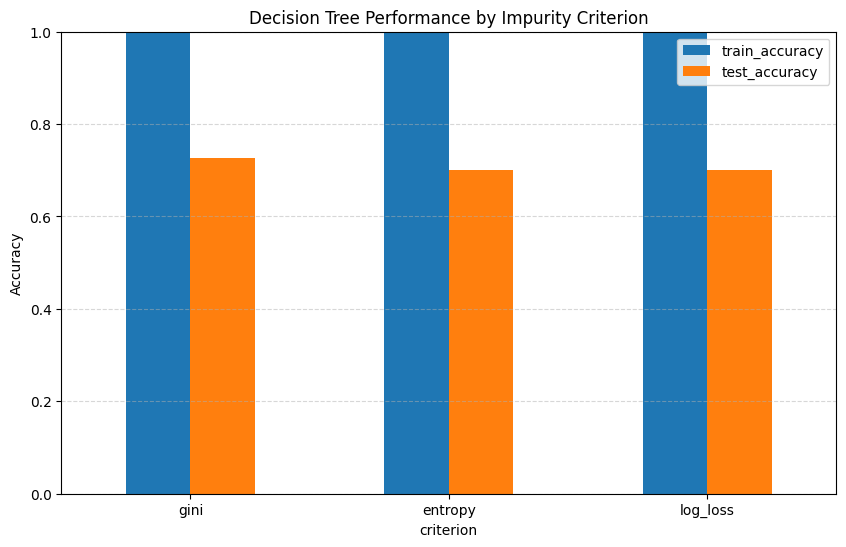

Best criterion: gini with test accuracy 0.7273


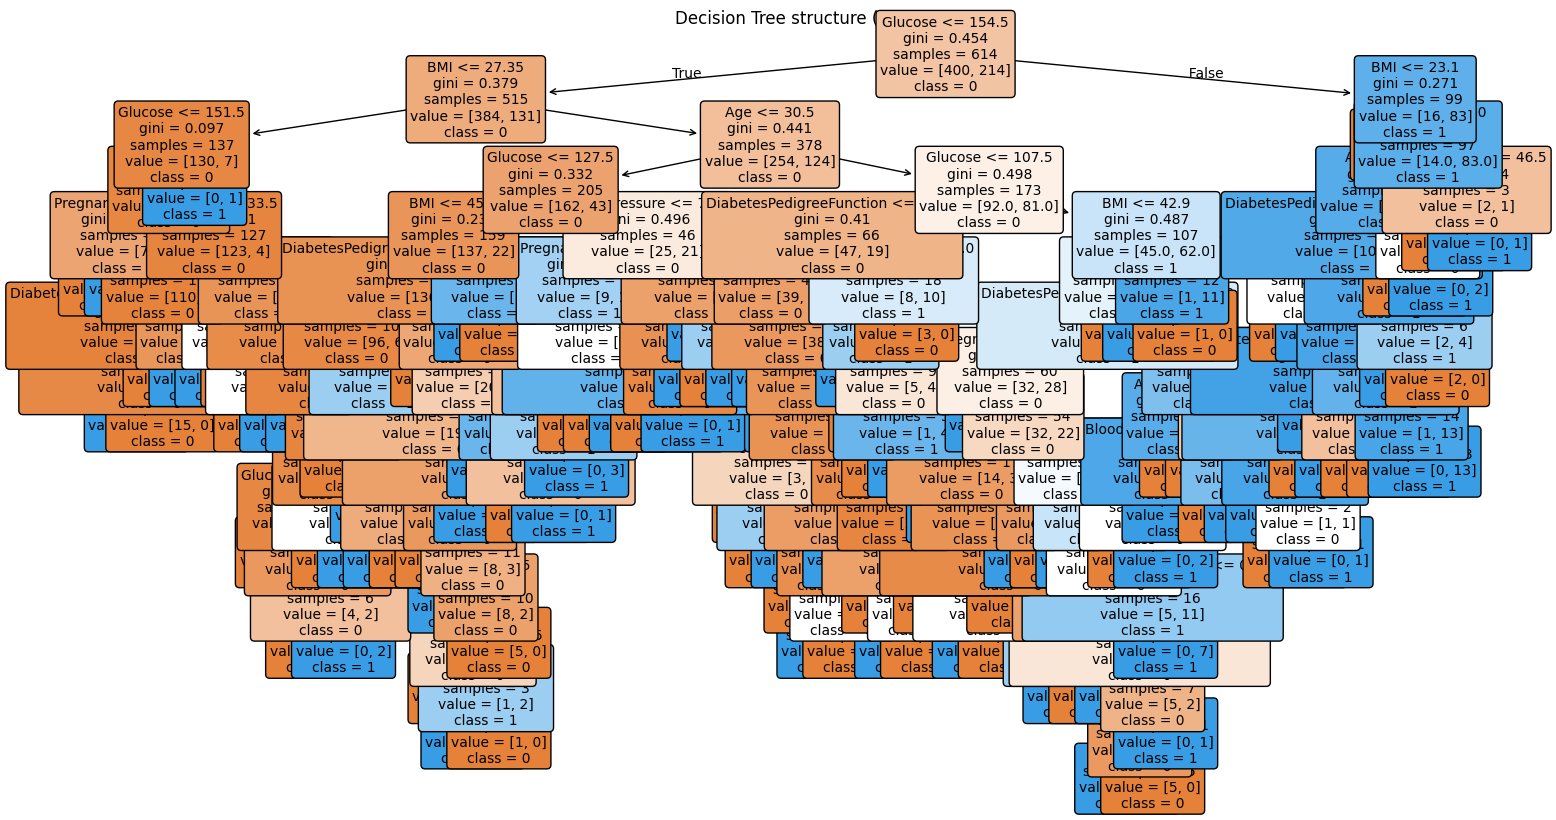

In [32]:
# Graph the performance comparison
if not results_df.empty:
    ax = results_df.set_index('criterion')[['train_accuracy', 'test_accuracy']].plot(kind='bar', figsize=(10, 6))
    ax.set_title('Decision Tree Performance by Impurity Criterion')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Accuracy')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=0)
    plt.show()

# Plot the best performing tree (by test accuracy)
if results:
    best = max(results, key=lambda row: row['test_accuracy'])
    print(f"Best criterion: {best['criterion']} with test accuracy {best['test_accuracy']:.4f}")
    plt.figure(figsize=(18, 10))
    plot_tree(
        best['model'],
        feature_names=X.columns,
        class_names=[str(c) for c in sorted(y.unique())],
        filled=True,
        rounded=True,
        impurity=True,
        fontsize=10
    )
    plt.title(f"Decision Tree structure ({best['criterion']})")
    plt.show()

## Step 4: Optimize the Best Decision Tree

Use the criterion that performed best in Step 3 and run a grid search over key decision tree hyperparameters. Evaluate the optimized model against the held-out test set.

In [33]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Determine the best criterion from the previous comparison
best_criterion = None
if not results_df.empty:
    best_criterion = results_df.sort_values('test_accuracy', ascending=False).iloc[0]['criterion']

if best_criterion is None:
    raise RuntimeError('No best criterion found from Step 3. Verify the previous model training cells.')

print('Best criterion selected for optimization:', best_criterion)

param_grid = {
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 4, 6],
    'criterion': [best_criterion],
    'splitter': ['best', 'random']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print('Best hyperparameters:')
print(grid.best_params_)
print(f"Best cross-validated accuracy: {grid.best_score_:.4f}")

best_tree = grid.best_estimator_

y_test_pred = best_tree.predict(X_test)

print('\nTest set performance for optimized tree:')
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print('Classification report:')
print(classification_report(y_test, y_test_pred, digits=4))

cm = confusion_matrix(y_test, y_test_pred)
print('Confusion matrix:')
print(cm)

Best criterion selected for optimization: gini
Fitting 5 folds for each of 160 candidates, totalling 800 fits


Best hyperparameters:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'}
Best cross-validated accuracy: 0.7525

Test set performance for optimized tree:
Accuracy: 0.7013
Classification report:
              precision    recall  f1-score   support

           0     0.7045    0.9300    0.8017       100
           1     0.6818    0.2778    0.3947        54

    accuracy                         0.7013       154
   macro avg     0.6932    0.6039    0.5982       154
weighted avg     0.6966    0.7013    0.6590       154

Confusion matrix:
[[93  7]
 [39 15]]


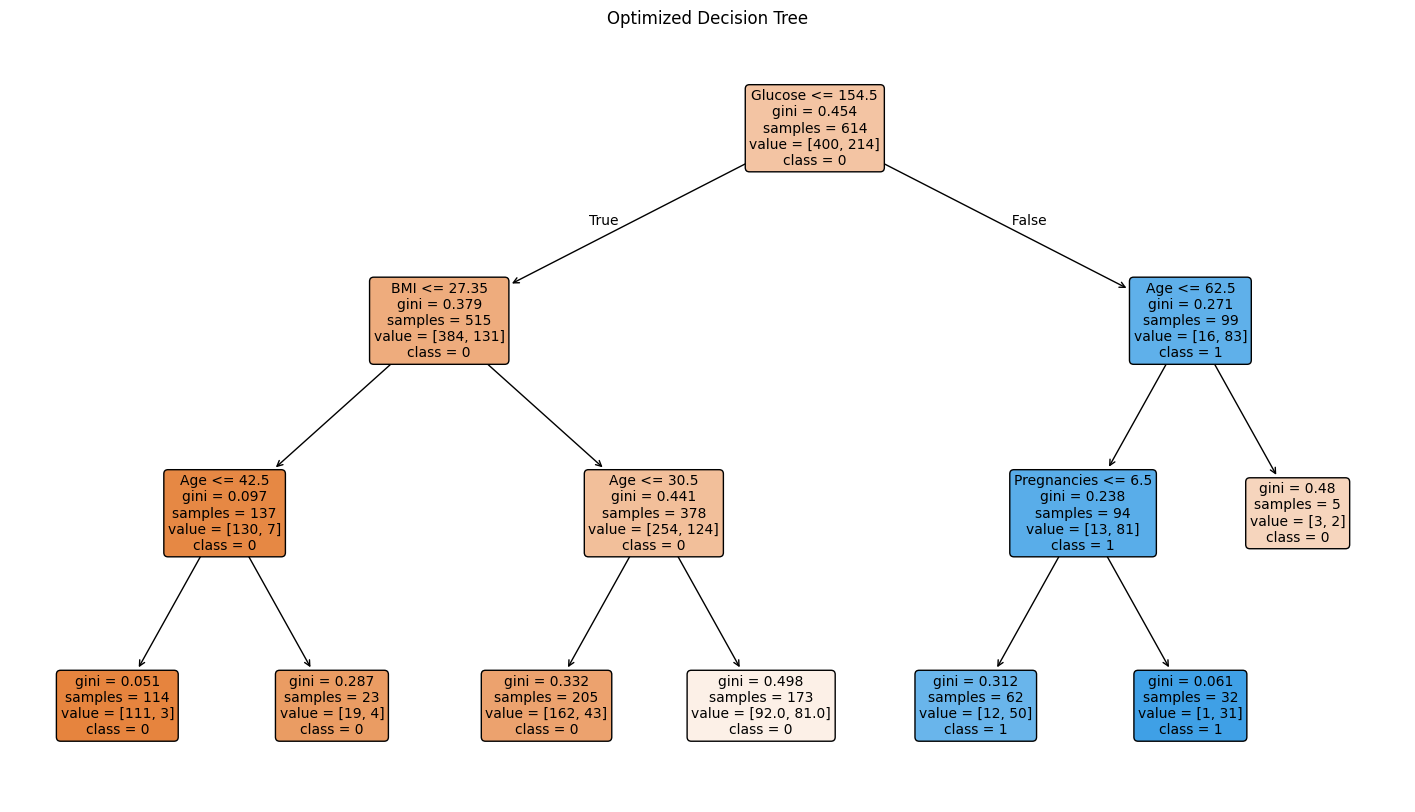

In [34]:
# Plot the optimized tree
plt.figure(figsize=(18, 10))
plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=10
)
plt.title('Optimized Decision Tree')
plt.show()

In [35]:
from pickle import dump

In [36]:
dump(clf, open("decision_tree_classifier_default_42.sav", "wb"))